# EDA общей схемы: Kaggle + Riot API

В этом ноутбуке анализируем данные, приведенные к общей схеме.

Важно: источники различаются по периоду, объему и способу сбора.

- `kaggle` — большая историческая база.
- `riot_api` — свежая собственная выборка, собранная через Riot API.

Поэтому сравниваем источники явно через поле `data_source`, а не смешиваем их без контекста.


## 1. Импорт библиотек и загрузка данных


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "normalized" / "all_matches_common.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "common_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STANDARD_POSITIONS = ["TOP", "JUNGLE", "MIDDLE", "BOTTOM", "UTILITY"]

common_df = pd.read_csv(DATA_PATH, dtype={"match_id": "string"}, low_memory=False)

print("Размер таблицы:", common_df.shape)
print("Источники:")
print(common_df["data_source"].value_counts())

common_df.head()


Размер таблицы: (25480, 48)
Источники:
data_source
kaggle      21910
riot_api     3570
Name: count, dtype: int64


,data_source,match_id,source_tier,game_start_utc,game_duration_sec,game_duration_min,game_mode,game_type,game_version,map_id,platform_id,queue_id,participant_id,puuid,summoner_id,summoner_name,summoner_level,champion_id,champion_name,team_id,win,team_position,individual_position,lane,role,kills,deaths,assists,kda,gold_earned,gold_spent,gold_per_min,total_damage_dealt_to_champions,damage_per_min,total_damage_taken,vision_score,vision_per_min,wards_placed,wards_killed,dragon_kills,baron_kills,item0,item1,item2,item3,item4,item5,item6
0,riot_api,EUW1_7875127465,challenger,2026-06-03 15:11:27,1305,21.750,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,1,bVsa8mfzUUhIQ5Y8ZcCY-Gn2wXZ_fMRdzrNwslEhELeJP3...,t8tExSPNiSG-56y-Xc_q3_jAUkU-7v2X7t9Yeh3fnfgd9y4,NaN,1258,58,Renekton,100,False,TOP,TOP,JUNGLE,NONE,2,3,1,1.000,7692,7025,353.655,8585,394.713,27470,21,0.966,7,2,0,0,1054,1028,3111,6631,1028,1037,3340
1,riot_api,EUW1_7875127465,challenger,2026-06-03 15:11:27,1305,21.750,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,2,dx95lhwSFR_6Z6tIZ-4hT2cJAQacOVCy1QkSPyKpLIDV_H...,uAfL8ZENMHJIYJucA5E43GxcFax0DXAABZzK2bLPuqbut-...,NaN,154,245,Ekko,100,False,JUNGLE,JUNGLE,JUNGLE,NONE,3,6,5,1.333,8371,7800,384.874,13364,614.437,22618,18,0.828,3,5,0,0,3115,1082,3100,1058,0,2422,3364
2,riot_api,EUW1_7875127465,challenger,2026-06-03 15:11:27,1305,21.750,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,3,QvKDaxIaW3M22FDi3laEO4UC16zVAQjAs4X8VO_csOiY_3...,i6rW2aOeSmSZidUFrzYofUOQgjOC_CN5rZM7effMU-9M9GYQ,NaN,424,136,AurelionSol,100,False,MIDDLE,MIDDLE,MIDDLE,SOLO,8,7,3,1.571,8685,8175,399.310,11393,523.816,21461,13,0.598,5,2,0,0,3116,3173,1082,6653,1056,1052,3364
3,riot_api,EUW1_7875127465,challenger,2026-06-03 15:11:27,1305,21.750,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,4,mzdMMvsch-WVRJhKTRz1JXj4FpxGQuihniUREjPJRRZHv-...,vPPDP62TX4txR5YMkYktzlShI9tdc7S0IDsRLHY0NSdKzVE,NaN,925,119,Draven,100,False,BOTTOM,BOTTOM,BOTTOM,SOLO,4,8,5,1.125,10152,9950,466.759,13150,604.598,14827,13,0.598,7,2,0,0,2523,6697,1055,3035,6670,0,3363
4,riot_api,EUW1_7875127465,challenger,2026-06-03 15:11:27,1305,21.750,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,5,XJDzfs5i32XRnays3RnZfHOF-KDacttRsVugqRbz1sdKBD...,1xgKUqyUjdxhL6nPgl4kdTwp8pI-ZI7TxNGI-edfDjG8eZDP,NaN,367,43,Karma,100,False,UTILITY,UTILITY,JUNGLE,NONE,1,5,9,2.000,6039,5380,277.655,5107,234.805,12654,73,3.356,27,12,0,0,3869,3107,2031,3158,4642,1028,3364


## 2. Проверка матчей и неполных записей

В полной записи матча должно быть 10 участников. В API-выборке все матчи полные, в Kaggle есть несколько неполных матчей.


In [2]:
match_quality = (
    common_df
    .groupby(["data_source", "match_id"])
    .size()
    .reset_index(name="participants")
)

match_quality_summary = (
    match_quality
    .groupby(["data_source", "participants"])
    .size()
    .reset_index(name="matches")
)

match_quality_summary


,data_source,participants,matches
0,kaggle,10,2191
1,riot_api,10,357


In [3]:
complete_match_ids = match_quality.loc[
    match_quality["participants"].eq(10),
    ["data_source", "match_id"],
]

complete_df = common_df.merge(
    complete_match_ids,
    on=["data_source", "match_id"],
    how="inner",
)

complete_positions_df = complete_df[
    complete_df["team_position"].isin(STANDARD_POSITIONS)
].copy()

print("Было строк:", len(common_df))
print("После исключения неполных матчей:", len(complete_df))
print("После фильтра стандартных ролей:", len(complete_positions_df))
print("Исключено строк неполных матчей:", len(common_df) - len(complete_df))


Было строк: 25480
После исключения неполных матчей: 25480
После фильтра стандартных ролей: 25469
Исключено строк неполных матчей: 0


### Вывод по качеству

Для сравнительного анализа используем `complete_df`, где оставлены только матчи с 10 участниками.

Для ролевых расчетов используем отдельную таблицу `complete_positions_df`: в ней оставлены только стандартные позиции `TOP`, `JUNGLE`, `MIDDLE`, `BOTTOM`, `UTILITY`. Это важно, потому что в Kaggle есть матчи ARAM и другие записи с `team_position = Invalid`; их нельзя напрямую сравнивать с ролями Summoner's Rift.


## 3. Обзор источников

Сравниваем объем данных, количество матчей, игроков и чемпионов.


In [4]:
source_overview = (
    complete_df
    .groupby("data_source")
    .agg(
        rows=("match_id", "size"),
        matches=("match_id", "nunique"),
        players=("puuid", "nunique"),
        champions=("champion_name", "nunique"),
        avg_game_duration_min=("game_duration_min", "mean"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

source_overview


,data_source,rows,matches,players,champions,avg_game_duration_min
0,kaggle,21910,2191,14294,169,28.251
1,riot_api,3570,357,1707,171,26.461


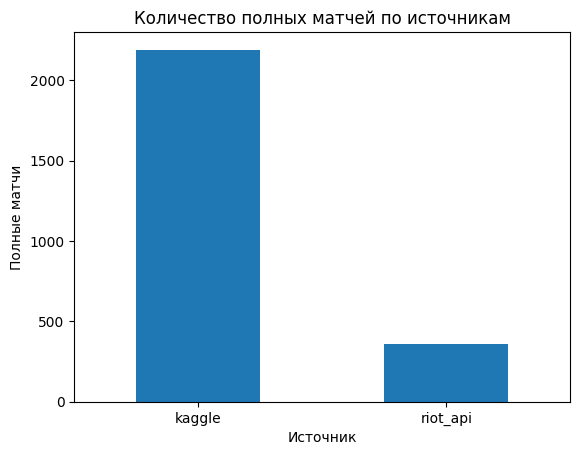

In [5]:
source_overview.plot(
    x="data_source",
    y="matches",
    kind="bar",
    legend=False,
    title="Количество полных матчей по источникам",
)
plt.xlabel("Источник")
plt.ylabel("Полные матчи")
plt.xticks(rotation=0)
plt.show()


### Вывод по источникам

Kaggle дает основной объем данных и лучше подходит для устойчивых статистических выводов. Riot API меньше по объему, но ценен как свежая собственная выборка и подтверждение работы ETL-пайплайна.


## 4. Роли по источникам

Смотрим, совпадают ли основные паттерны ролей в Kaggle и API.


In [6]:
source_role_stats = (
    complete_positions_df
    .groupby(["data_source", "team_position"])
    .agg(
        rows=("match_id", "size"),
        matches=("match_id", "nunique"),
        avg_kda=("kda", "mean"),
        avg_damage_per_min=("damage_per_min", "mean"),
        avg_gold_per_min=("gold_per_min", "mean"),
        avg_vision_per_min=("vision_per_min", "mean"),
    )
    .reset_index()
    .sort_values(["data_source", "team_position"])
)

source_role_stats


,data_source,team_position,rows,matches,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min
0,kaggle,BOTTOM,4381,2191,3.276,815.034,424.155,0.532
1,kaggle,JUNGLE,4382,2191,3.847,666.293,409.161,0.708
2,kaggle,MIDDLE,4378,2191,3.359,830.477,405.116,0.559
3,kaggle,TOP,4378,2191,2.661,799.083,399.354,0.528
4,kaggle,UTILITY,4380,2191,4.032,422.281,294.020,1.939
5,riot_api,BOTTOM,714,357,3.547,881.256,499.620,0.691
6,riot_api,JUNGLE,714,357,4.521,692.334,462.724,0.974
7,riot_api,MIDDLE,714,357,3.567,838.793,437.050,0.716
8,riot_api,TOP,714,357,2.770,763.429,412.876,0.818
9,riot_api,UTILITY,714,357,4.226,387.820,313.931,2.872


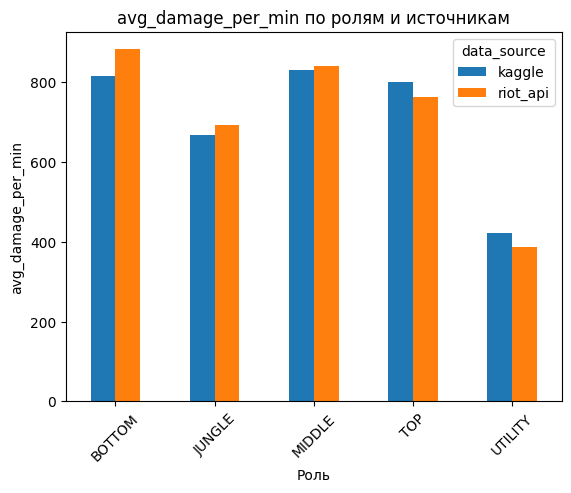

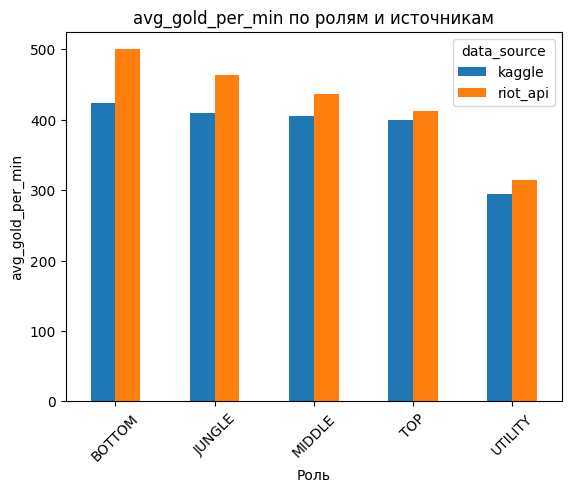

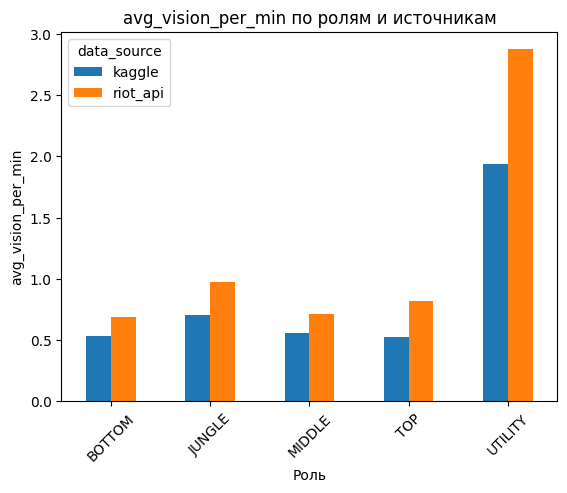

In [7]:
for metric in ["avg_damage_per_min", "avg_gold_per_min", "avg_vision_per_min"]:
    pivot = source_role_stats.pivot(
        index="team_position",
        columns="data_source",
        values=metric,
    )
    pivot.plot(kind="bar", title=f"{metric} по ролям и источникам")
    plt.xlabel("Роль")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.show()


### Вывод по ролям

Этот блок нужен, чтобы проверить устойчивость ролевых паттернов. Для него используются только стандартные позиции Summoner's Rift, без `Invalid`.

Если в обоих источниках BOTTOM лидирует по урону, а UTILITY по vision score, такой вывод можно использовать увереннее.


## 5. Победители и проигравшие по источникам

Сравниваем, одинаково ли отличаются победители от проигравших в Kaggle и API.


In [8]:
source_result_stats = (
    complete_df
    .groupby(["data_source", "win"])
    .agg(
        rows=("match_id", "size"),
        avg_kda=("kda", "mean"),
        avg_damage_per_min=("damage_per_min", "mean"),
        avg_gold_per_min=("gold_per_min", "mean"),
        avg_vision_per_min=("vision_per_min", "mean"),
        avg_kills=("kills", "mean"),
        avg_deaths=("deaths", "mean"),
        avg_assists=("assists", "mean"),
    )
    .reset_index()
)

source_result_stats["result"] = source_result_stats["win"].map({False: "loss", True: "win"})
source_result_stats


,data_source,win,rows,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min,avg_kills,avg_deaths,avg_assists,result
0,kaggle,False,10955,1.666,638.591,354.518,0.821,4.697,7.210,6.412,loss
1,kaggle,True,10955,5.201,773.995,418.056,0.885,7.193,4.716,10.211,win
2,riot_api,False,1785,1.656,644.883,389.330,1.172,4.064,6.580,5.969,loss
3,riot_api,True,1785,5.796,780.570,461.150,1.257,6.568,4.082,10.022,win


In [ ]:
# Метрики имеют разный масштаб (kda ~5, damage ~780, gold ~450), поэтому на одной
# оси Y мелкие столбцы kda не видно. Рисуем каждую метрику в своей панели
# с собственной осью Y и подписываем значения. Цвета: loss — красный, win — зелёный.
metrics = ["avg_kda", "avg_damage_per_min", "avg_gold_per_min", "avg_vision_per_min"]

for source in source_result_stats["data_source"].unique():
    plot_df = (
        source_result_stats
        .query("data_source == @source")
        .set_index("result")[metrics]
    )

    fig, axes = plt.subplots(1, len(metrics), figsize=(14, 3.5))
    fig.suptitle(f"Победители vs проигравшие: {source}")

    for ax, metric in zip(axes, metrics):
        plot_df[metric].plot(kind="bar", ax=ax, color=["#d9534f", "#5cb85c"], legend=False)
        ax.set_title(metric.replace("avg_", ""))
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
        for i, value in enumerate(plot_df[metric]):
            ax.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

### Вывод по победителям и проигравшим

Этот срез подходит для финального дашборда: он понятен и хорошо показывает, какие игровые показатели связаны с победой. Сравнение по источникам помогает отделить устойчивые паттерны от особенностей конкретной выборки.


## 6. Чемпионы по источникам

Для чемпионов используем порог по числу игр внутри источника. Иначе в топ winrate попадут случайные редкие пики.


In [10]:
MIN_GAMES_BY_SOURCE = {
    "kaggle": 30,
    "riot_api": 10,
}

champion_source_stats = (
    complete_df
    .groupby(["data_source", "champion_name"])
    .agg(
        games=("match_id", "nunique"),
        wins=("win", "sum"),
        winrate=("win", "mean"),
        avg_kda=("kda", "mean"),
        avg_damage_per_min=("damage_per_min", "mean"),
        avg_gold_per_min=("gold_per_min", "mean"),
        avg_vision_per_min=("vision_per_min", "mean"),
    )
    .reset_index()
)

champion_source_stats["min_games"] = champion_source_stats["data_source"].map(MIN_GAMES_BY_SOURCE)
champion_source_filtered = (
    champion_source_stats
    .query("games >= min_games")
    .sort_values(["data_source", "winrate", "games"], ascending=[True, False, False])
)

champion_source_filtered.head(30)


,data_source,champion_name,games,wins,winrate,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min,min_games
134,kaggle,Taric,62,40,0.645,5.698,275.530,300.981,1.753,30
120,kaggle,Shyvana,38,24,0.632,3.460,771.349,429.882,0.681,30
19,kaggle,Briar,69,42,0.609,3.140,828.499,432.112,0.687,30
34,kaggle,Fiora,55,33,0.600,3.225,863.325,430.910,0.510,30
124,kaggle,Skarner,126,75,0.595,5.563,665.849,374.034,0.678,30
81,kaggle,Milio,163,96,0.589,5.850,227.349,274.819,2.005,30
142,kaggle,Udyr,67,39,0.582,3.302,605.696,398.313,0.722,30
101,kaggle,Qiyana,64,37,0.578,3.357,787.585,415.012,0.614,30
92,kaggle,Nilah,45,26,0.578,2.845,769.943,439.876,0.477,30
79,kaggle,Maokai,156,90,0.577,4.007,605.552,324.729,1.197,30


In [11]:
popular_champions_by_source = (
    champion_source_stats
    .sort_values(["data_source", "games"], ascending=[True, False])
    .groupby("data_source")
    .head(15)
)

popular_champions_by_source


,data_source,champion_name,games,wins,winrate,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min,min_games
82,kaggle,MissFortune,423,223,0.527,3.182,832.114,430.825,0.574,30
20,kaggle,Caitlyn,421,207,0.492,2.991,773.479,420.242,0.531,30
54,kaggle,Jinx,411,205,0.499,3.097,791.043,421.496,0.515,30
75,kaggle,Lulu,405,202,0.499,5.012,286.913,282.237,2.033,30
150,kaggle,Viego,362,186,0.514,3.908,645.158,417.695,0.701,30
53,kaggle,Jhin,358,194,0.542,4.183,761.490,429.661,0.514,30
76,kaggle,Lux,345,180,0.522,3.953,769.170,358.340,1.170,30
83,kaggle,MonkeyKing,324,176,0.543,4.603,666.260,415.246,0.719,30
151,kaggle,Viktor,312,154,0.494,3.263,924.254,402.756,0.545,30
32,kaggle,Ezreal,299,154,0.515,3.481,893.546,408.203,0.498,30


### Вывод по чемпионам

Для финального анализа лучше показывать отдельно популярность чемпионов и winrate. Популярность отражает мету и предпочтения игроков, а winrate требует фильтра по числу игр.


## 7. Сохранение агрегатов для дашборда


In [12]:
source_overview.to_csv(OUTPUT_DIR / "common_source_overview.csv", index=False)
source_role_stats.to_csv(OUTPUT_DIR / "common_source_role_stats.csv", index=False)
source_result_stats.to_csv(OUTPUT_DIR / "common_source_result_stats.csv", index=False)
champion_source_stats.to_csv(OUTPUT_DIR / "common_champion_source_stats.csv", index=False)
champion_source_filtered.to_csv(OUTPUT_DIR / "common_champion_source_filtered.csv", index=False)
popular_champions_by_source.to_csv(OUTPUT_DIR / "common_popular_champions_by_source.csv", index=False)

print("Агрегаты сохранены в:", OUTPUT_DIR)


Агрегаты сохранены в: c:\Users\fiery\OneDrive\Рабочий стол\учеба, фото\Дата аналитик\Проект LOL\outputs\common_eda


## 8. Итог

- API и Kaggle приведены к единой схеме, но источники не смешиваются без контекста.
- Для сравнения используем `data_source`.
- Для расчетов по ролям и командам используем только полные матчи.
- Kaggle дает масштаб, Riot API дает свежесть и демонстрирует собственный ETL.
- Для дашборда нужен фильтр по источнику данных.
